In [1]:
from decimal import Decimal, getcontext
import matplotlib.pyplot as plt

tolerance = 100

getcontext().prec = tolerance

R = Decimal('0.35') 
c_light = Decimal('3.0e10') 
T0 = Decimal('1.0e4') 
Tw = Decimal('2000')
p_exp = 4  
A_p = Decimal('3.084e-4')
B_p = Decimal('4.799e4')

T_data = [
    Decimal('2000'), Decimal('3000'), Decimal('4000'),
    Decimal('5000'), Decimal('6000'), Decimal('7000'),
    Decimal('8000'), Decimal('9000'), Decimal('10000')
]

k_data_variant1 = [
    Decimal('8.200e-03'), Decimal('2.768e-02'), Decimal('6.560e-02'),
    Decimal('1.281e-01'), Decimal('2.214e-01'), Decimal('3.516e-01'),
    Decimal('5.248e-01'), Decimal('7.472e-01'), Decimal('1.025e+00')
]

k_data_variant2 = [
    Decimal('1.600e+00'),
    Decimal('5.400e+00'),
    Decimal('1.280e+01'),
    Decimal('2.500e+01'),
    Decimal('4.320e+01'),
    Decimal('6.860e+01'),
    Decimal('1.024e+02'),
    Decimal('1.458e+02'),
    Decimal('2.000e+02')
]

In [2]:
def create_k_interpolator(T_vals, k_vals):
    for i in range(len(T_vals) - 1):
        if T_vals[i] >= T_vals[i + 1]:
            raise ValueError("Массив T_data должен быть строго возрастающим.")

    lnT = [t.ln() for t in T_vals]
    lnK = [k.ln() for k in k_vals]

    def k_of_T(T: Decimal) -> Decimal:
        x = T.ln()

        if T < T_vals[0]:
            x0, x1 = lnT[0], lnT[1]
            y0, y1 = lnK[0], lnK[1]
            # y = y0 + (y1 - y0)*( (x - x0)/(x1 - x0) )
            slope = (y1 - y0) / (x1 - x0)
            y = y0 + slope*(x - x0)
            return y.exp()

        if T > T_vals[-1]:
            x0, x1 = lnT[-2], lnT[-1]
            y0, y1 = lnK[-2], lnK[-1]
            slope = (y1 - y0) / (x1 - x0)
            y = y0 + slope*(x - x0)
            return y.exp()

        for i in range(len(lnT) - 1):
            if x >= lnT[i] and x <= lnT[i + 1]:
                y0, y1 = lnK[i], lnK[i + 1]
                x0, x1 = lnT[i], lnT[i + 1]
                slope = (y1 - y0) / (x1 - x0)
                y = y0 + slope*(x - x0)
                return y.exp()

        return Decimal('0')

    return k_of_T


k_of_T = create_k_interpolator(T_data, k_data_variant2)

def k_of_r(r: Decimal) -> Decimal:
    return k_of_T( T_of_r(r) )


def T_of_r(r: Decimal) -> Decimal:
    ratio = r / R
    return T0 + (Tw - T0) * (ratio ** p_exp)

def U_p_of_r(r: Decimal) -> Decimal:
    T_val = T_of_r(r)
    exponent = (B_p / T_val).exp() 
    return A_p / (exponent - Decimal('1'))


def derivatives(r: Decimal, y: tuple[Decimal, Decimal]) -> tuple[Decimal, Decimal]:
    U, F = y
    k_val = k_of_r(r)
    Up = U_p_of_r(r)

    dU = -(Decimal('3')*k_val/c_light)*F

    if r == 0:
        dF = -(c_light*k_val)*(U - Up)
    else:
        dF = -(c_light*k_val)*(U - Up) - F/r

    return (dU, dF)


def rk2_step(f, r: Decimal, y: tuple[Decimal, Decimal], h: Decimal) -> tuple[Decimal, Decimal]:
    k1 = f(r, y)
    y_mid = (y[0] + (h/Decimal('2'))*k1[0],
             y[1] + (h/Decimal('2'))*k1[1])
    k2 = f(r + h/Decimal('2'), y_mid)
    y_new = (y[0] + h*k2[0], y[1] + h*k2[1])
    return y_new

def rk4_step(f, r: Decimal, y: tuple[Decimal, Decimal], h: Decimal) -> tuple[Decimal, Decimal]:
    k1 = f(r, y)
    y2 = (y[0] + (h/Decimal('2'))*k1[0],
          y[1] + (h/Decimal('2'))*k1[1])
    k2 = f(r + h/Decimal('2'), y2)
    y3 = (y[0] + (h/Decimal('2'))*k2[0],
          y[1] + (h/Decimal('2'))*k2[1])
    k3 = f(r + h/Decimal('2'), y3)
    y4 = (y[0] + h*k3[0], y[1] + h*k3[1])
    k4 = f(r + h, y4)

    # Итог
    dU = (k1[0] + k2[0]*Decimal('2') + k3[0]*Decimal('2') + k4[0])*(h/Decimal('6'))
    dF = (k1[1] + k2[1]*Decimal('2') + k3[1]*Decimal('2') + k4[1])*(h/Decimal('6'))

    return (y[0] + dU, y[1] + dF)

def solve_ivp_shooting(phi: Decimal, method='rk4', Nsteps=5000, flag=False):
    U0 = phi*U_p_of_r(Decimal('0'))
    F0 = Decimal('0')
    y  = (U0, F0)

    r_vals = []
    U_vals = []
    F_vals = []

    step_func = rk4_step if method=='rk4' else rk2_step

    h = R / Decimal(Nsteps)
    r = Decimal('0')

    r_vals.append(r)
    U_vals.append(y[0])
    F_vals.append(y[1])

    for i in range(Nsteps):
        y = step_func(derivatives, r, y, h)
        
        # if (flag):
        #     print(y)
        # if (i % 100 == 0):
        #     print(y)
        
        r = r + h
        r_vals.append(r)
        U_vals.append(y[0])
        F_vals.append(y[1])

    return r_vals, U_vals, F_vals

def boundary_mismatch(phi: Decimal, method='rk4') -> Decimal:
    r_vals, U_vals, F_vals = solve_ivp_shooting(phi, method)
    return F_vals[-1] - Decimal('0.39')*c_light*U_vals[-1]

def find_phi(phi_left: Decimal, phi_right: Decimal, method='rk4', tol=Decimal('1e-10')):
    f_left = boundary_mismatch(phi_left, method)
    f_right = boundary_mismatch(phi_right, method)
    if f_left*f_right > Decimal('0'):
        raise ValueError(f"Функция не меняет знак на [{phi_left},{phi_right}]"
                         f"\nG({phi_left})={f_left}, G({phi_right})={f_right}")

    for iteration in range(1000):
        mid = (phi_left + phi_right)/Decimal('2')
        f_mid = boundary_mismatch(mid, method)
        
        print(f"[{iteration:03d}] phi = {mid}  G(phi) = {f_mid}")

        if f_mid == Decimal('0'):
            return mid
        if abs(f_mid) < tol:
            return mid

        if f_left*f_mid>Decimal('0'):
            phi_left = mid
            f_left = f_mid
        else:
            phi_right = mid
            f_right = f_mid

        if (phi_right - phi_left).copy_abs() < tol:
            return (phi_left + phi_right)/Decimal('2')

    return (phi_left + phi_right)/Decimal('2')

In [3]:
import math

phi_min = Decimal('0')
phi_max = Decimal('1')

phi_solution_rk4 = find_phi(phi_min, phi_max, method='rk4', tol=Decimal('1e-50'))
print("Найдено phi (RK4) =", phi_solution_rk4)

r_vals_dec, U_vals_dec, F_vals_dec = solve_ivp_shooting(phi_solution_rk4, method='rk4', flag=True)

# phi_solution_rk2 = find_phi(phi_min, phi_max, method='rk2')
# print("Найдено phi (RK2) =", phi_solution_rk2)
# 
# r2_dec, U2_dec, F2_dec = solve_ivp_shooting(phi_solution_rk2, method='rk2')

r_vals = [float(r) for r in r_vals_dec]
U_vals = [float(u) for u in U_vals_dec]
F_vals = [float(f) for f in F_vals_dec]
# r_vals2 = [float(r) for r in r2_dec]
# U_vals2 = [float(u) for u in U2_dec]
# F_vals2 = [float(f) for f in F2_dec]

Up_vals = [float(U_p_of_r(rr)) for rr in r_vals_dec]

plt.show()

[000] phi = 0.5  G(phi) = 4639037033408569700912828179878412680730.152647902571342118782734417995117857828086711426361069608327
[001] phi = 0.75  G(phi) = 2319513198189160337795783926426803540297.616691958706944103923587378474803303412042498778538559925640
[002] phi = 0.875  G(phi) = 1159751280579455656237261799700998970081.348713986774745096494013858714646026204020392454627305084270
[003] phi = 0.9375  G(phi) = 579870321774603315458000736338096684973.2147250008086455927792270988345673876000093392926716776636041
[004] phi = 0.96875  G(phi) = 289929842372177145068370204656645542419.1477305078255958409218337188945280682980038127116938639532557
[005] phi = 0.984375  G(phi) = 144959602670964059873554938815919971142.1142332613340709649931370289245084086470010494212049570980826
[006] phi = 0.9921875  G(phi) = 72474482820357517276147305895557185503.59748463808830852702878868393949857882149966777596050367049587
[007] phi = 0.99609375  G(phi) = 36231922895054245977443489435375792684.33911032646

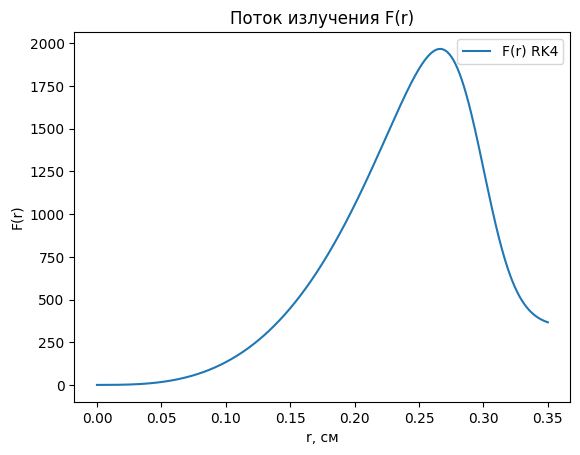

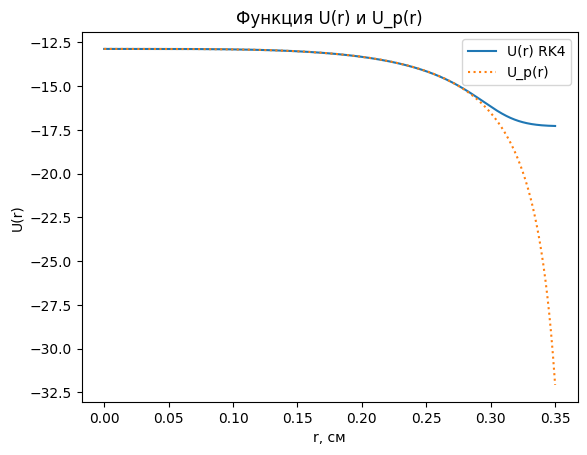

In [4]:
U_vals_log = [math.log(uval) for uval in U_vals]
Up_vals_log = [math.log(upval) for upval in Up_vals]

plt.figure()
plt.plot(r_vals, F_vals, label="F(r) RK4")
# plt.plot(r_vals2, F_vals2, '--', label="F(r) RK2")
plt.xlabel("r, см")
plt.ylabel("F(r)")
plt.title("Поток излучения F(r)")
plt.legend()
plt.show()

plt.figure()
plt.plot(r_vals, U_vals_log, label="U(r) RK4")
# plt.plot(r_vals2, U_vals2, '--', label="U(r) RK2")
plt.plot(r_vals, Up_vals_log, ':', label="U_p(r)")
plt.xlabel("r, см")
plt.ylabel("U(r)")
plt.title("Функция U(r) и U_p(r)")
plt.legend()
plt.show()